# Assignment-Principal Component Analysis

Task:
* Apply PCA to reduce data into 2 dimensions
* Visualize the transformed data
* Explain how PCA changes the data representation
* What is the difference between original data and PCA result?
* Submit the assignment as a practical report in PDF format

TODO:
* Create 2 classes of data (Chilli, cucumber, blueberry)
* Create 4 variables corressponding to the classes atribute (color(wavelength(nm)), fruit length (in cm), plant height (in cm), glucose level(in grams per 100 g))

In [12]:
# Setup
import pandas as pd
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
# Dataset creation
plant = ["chili", "cucumber", "blueberry"]
plant_list = []
fruit_length = []
plant_height = []
spectrum = []
glucose = []

for i in range(90):
    selected = plant[random.randint(0,2)] 
    if selected == "chili":
        plant_list.append(selected)
        fruit_length.append(4 + random.uniform(-2,2))
        plant_height.append(80 + random.uniform(-20,20))
        spectrum.append(700 +  random.uniform(-20, 20))
        glucose.append(2.3 + random.uniform(-0.2, 0.2))
    elif selected == "cucumber":
        plant_list.append(selected)
        fruit_length.append(25 + random.uniform(-2,2))
        plant_height.append(130 + random.uniform(-20,20))
        spectrum.append(520 +  random.uniform(-20, 20))
        glucose.append(0.7 + random.uniform(-0.2, 0.2))
    else:
        plant_list.append(selected)
        fruit_length.append(1 + random.uniform(-0.2,0.2))
        plant_height.append(200 + random.uniform(-20,20))
        spectrum.append(450 +  random.uniform(-20, 20))
        glucose.append(4.8 + random.uniform(-0.2, 0.2))
        


In [6]:
df = pd.DataFrame({
    "fruit_length": fruit_length,
    "plant_height": plant_height,
    "spectrum": spectrum,
    "glucose": glucose,
    "plant_list": plant_list
})

In [7]:
df.head()

,fruit_length,plant_height,spectrum,glucose,plant_list
0,0.841031,207.160875,439.891975,4.897691,blueberry
1,5.550230,67.917194,687.178303,2.471236,chili
2,3.659282,81.297088,704.328325,2.228431,chili
3,23.503052,135.354361,529.476626,0.690387,cucumber
4,5.705450,79.860829,711.959029,2.488860,chili


In [10]:
df.shape

(90, 5)

In [15]:
# Splitting data into feautures and classes

X = df.drop(columns="plant_list")
y = df["plant_list"]

In [17]:
X.head()

,fruit_length,plant_height,spectrum,glucose
0,0.841031,207.160875,439.891975,4.897691
1,5.550230,67.917194,687.178303,2.471236
2,3.659282,81.297088,704.328325,2.228431
3,23.503052,135.354361,529.476626,0.690387
4,5.705450,79.860829,711.959029,2.488860


In [18]:
y.head()

0    blueberry
1        chili
2        chili
3     cucumber
4        chili
Name: plant_list, dtype: str

In [19]:
# Preprocessing 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Initialising PCA and fitting 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [22]:
X_pca

array([[ 2.11070733e+00,  7.60382368e-02],
       [-1.39758503e+00, -9.59657240e-01],
       [-1.34847491e+00, -1.07059286e+00],
       [-1.34398041e+00,  1.92275998e+00],
       [-1.38069922e+00, -9.97198156e-01],
       [-1.44557763e+00, -1.29984923e+00],
       [-1.39366036e+00,  2.00663902e+00],
       [ 2.02800018e+00,  9.67525622e-02],
       [ 2.04386543e+00,  1.62555852e-01],
       [-1.55349813e+00, -9.47211719e-01],
       [-1.53561415e+00, -1.09514801e+00],
       [ 1.87881935e+00, -3.08505696e-03],
       [ 2.09454314e+00,  1.03112115e-01],
       [ 1.84516875e+00, -9.88572239e-02],
       [-1.27710563e+00, -8.73155393e-01],
       [ 2.01867364e+00,  8.93692565e-02],
       [ 1.86513501e+00, -1.26139418e-01],
       [ 1.95664718e+00,  1.30111861e-02],
       [-1.24848212e+00,  2.04331897e+00],
       [ 1.84836398e+00, -9.13010124e-03],
       [ 1.86681257e+00,  3.62537920e-03],
       [-1.49975062e+00, -1.12304061e+00],
       [-1.44967071e+00,  2.09100225e+00],
       [-1.

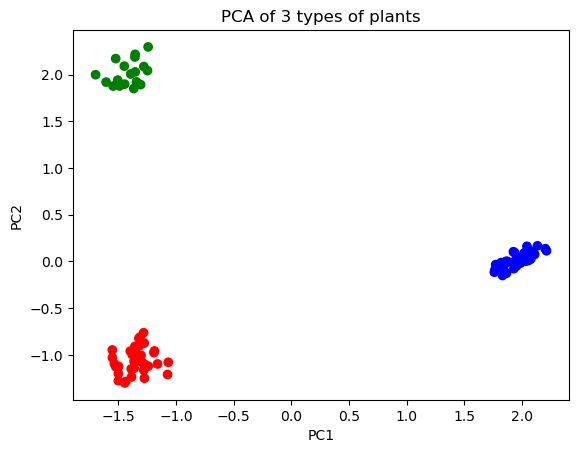

<Figure size 1000x600 with 0 Axes>

In [27]:
# Visualization
import matplotlib.pyplot as plt

plt.title("PCA of 3 types of plants")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.scatter(x=X_pca[:,0], y=X_pca[:,1], c=y.map({"chili": "red", "cucumber": "green", "blueberry": "blue"}))
plt.figure(figsize=(10,6))
plt.show()